# LAB 1 -- DAY 3B -- Case 2 t-test

Sometimes we need to compare two sets of data. For example, if there are two different technicians measuring students at different locations using different thermometers, those two data sets can NOT be treated as one big data set.

In this case, the two thermometers were obtained from the same company and used by two different technicians to measure the forehead temperatures of 20 students.

Task: determine if the two thermometers produce data sets that are statistically significantly different.

Steps:
1. Read the CSV file and put the data into two separate data lists
2. Calculate basic statistics for each data set
3. Find $f_{calc}$ and $f_{table}$
4. Compare $f_{calc}$ and $f_{table}$ to determine whether you should use case 2a or case 2b equations
5. Calculate $t_{calc}$ and degrees of freedom (dof) using case determined above
5. Calculate $t_{table}$
6. Compare $t_{calc}$ and $t_{table}$ to determine if the data is different at 95% statistical level

Don't forget to complete the TODOs scattered throughout and appropriately replace 'None' with your implementation. Make sure to run each code cell, especially after you modify it.

<br>

EXCEL TIME (for me): 21 mins 3 secs, doing a complicated equation in excel is HORRIBLE

## First step: importing and reading the CSV (data) file

Just like the previous parts, you will upload the correct CSV file, "case2.csv".

In [ ]:
# importing a file from your computer
# using one of google colab's libraries
from google.colab import files

# files.upload() opens a file picker so you can upload a (CSV) file from your computer
# the uploaded file is stored in the Colab session so Python can read the data inside it
# note: you only have to upload once. after that, it should save the file and you can press "cancel upload" to skip this step
# in the case it doesn't save the file, then just reupload.
uploaded = files.upload()

# TODO FOR STUDENT
# click run -> choose files -> select 'case2.csv'
# after it uploads successfully, continue running the remaining cells

Saving case2.csv to case2.csv


## How do we add our data to the list if there's two different data sets??

As mentioned in a prior notebook, sometimes a CSV file contains more than one column of data. In this case, since we are comparing the data collected from two different technicians, there are two columns.

To differentiate between the two, we are going to change the row index. Previously, we would loop through each row in the file and append the value *row[0]* to the data list. Now, we will use two different lists. The first list will add each value with index=0 to represent the first column, and the second one will have each value with index=1 for the second column.

Remember: indexes start at 0 and go to n-1.

In [ ]:
# 1. importing csv so we can read our file
import csv

# 2. creating 2 lists to store our values
data_list1 = []
data_list2 = []

# 3. reading the file line by line and adding each value to data list
# note: if this doesn't work, check the file name is correct. feel free to update if needed
with open("case2.csv", "r") as f:      # opening "case2.csv" in read mode using f to call our file

    # 4. uses csv library to read our file f and put into variable called data
    data = csv.reader(f)

    # 5. we are looping through each row in our data.
    for row in data:

      # 6. adding the data into the data lists

      # TODO FOR STUDENT
      data_list1.append(float(row[0]))
      data_list2.append(float(row[1]))

# printing data_list to confirm it was read correctly
print(f"data_list1 = {data_list1}")
print(f"data_list2 = {data_list2}")

data_list1 = [37.5, 36.9, 37.1, 37.0, 37.0, 37.1, 36.6, 36.8, 37.0, 37.4, 36.9, 36.0, 36.5, 36.3, 36.4, 37.1, 36.9, 37.0, 37.8, 37.1]
data_list2 = [37.4, 37.1, 37.7, 37.1, 37.5, 37.4, 37.2, 37.1, 37.1, 37.4, 37.5, 37.4, 37.4, 37.1, 37.3, 37.1, 37.1, 37.6, 37.2, 37.1]


## $f_{calc}$

Before we can perform the t-test, we first need to determine whether the two data sets have similar variability. We do this by comparing their variances using an f-test. The result tells us whether we should use the Case 2a or Case 2b equations.

We will use the following equation:

$$f_{calc} = \frac{s_{1}^2}{s_2^2}$$

where:
* $s_1$ = larger sample standard deviation
* $s_2$ = smaller sample standard deviation

NOTE: it's important that you always put the bigger standard deviation ($s_1$) on top so that $f_{calc}$  > 1 !!!

For this notebook, we will need several statistical values:
* mean (average)
* standard deviation

Make sure you run the code for each function below so that you can use them!!

In [ ]:
# @title average(data_list)
def average(data_list):
  sum = 0                       # init sum to 0
  data_length = len(data_list)  # find number of values in list

  # sum up each value in data_list
  for i in range(data_length):
    sum += data_list[i]         # sum = sum + data_list[i]

  # find the average of the data list
  average = sum / data_length

  # returns average
  return average

In [ ]:
# @title sample_sd(data_list)
import math                         # to take square root

def sample_sd(data_list):
  sum_of_deviances = 0              # initialize sum to 0
  data_length = len(data_list)      # find length of data

  # calculate average
  avg = average(data_list)          # use function we made to find average

  # find deviations from mean for each data point
  for i in range(data_length):
    deviation = data_list[i] - avg  # subract mean from each data point
    squared_d = (deviation ** 2)    # square the deviation to ensure all positive values
    sum_of_deviances += squared_d   # sum all squared deviations

  # divide sum by (n-1) where n is the data_length
  variance = sum_of_deviances / (data_length - 1)

  # take square root to give sample standard deviation and return it
  sample_sd = math.sqrt(variance)
  return sample_sd

## Let's find the statistics for each data list

To do this, use the following functions that were defined above:
* **average(data_list)** --> returns average of data_list
* **sample_sd(data_list)** --> returns sample standard deviation of data_list
* **len(data_list)** --> returns length of data_list


In [ ]:
# calculate basic stats like before

# TODO FOR STUDENT
# average
avg1 = average(data_list1)
avg2 = average(data_list2)

# sample sd
sd1 = sample_sd(data_list1)
sd2 = sample_sd(data_list2)

# number of data points
n1 = len(data_list1)
n2 = len(data_list2)

# printing all of the values
print(f"x_bar1 = {avg1} \nx_bar2 = {avg2}")
print(f"sd1 = {sd1} \nsd2 = {sd2}")
print(f"n1 = {n1} \nn2 = {n2}")

x_bar1 = 36.919999999999995 
x_bar2 = 37.290000000000006
sd1 = 0.41624891338565306 
sd2 = 0.1943951483041959
n1 = 20 
n2 = 20


## Finding $f_{calc}$

Use the equation: $$f_{calc} = \frac{s_{1}^2}{s_2^2}$$

Remember to choose the larger sd for $s_{1}$ (numerator) so that $f_{calc}$ > 1.

In [ ]:
# choose values for s_1 and s_2
# remember the LARGER standard deviation must be s1 (numerator)

# TODO FOR STUDENT
f_calc = (sd1**2) / (sd2**2)

# printing value
print(f"f_calc = {f_calc}")

Fcalc = 4.584958217270221


## $f_{table}$

Run the following function, and then use the function to find $f_{table}$.


* **f_inv(sig_val, dof1, dof2)** --> returns $f_{table}$, where parameters are:
    * sig_val = 0.05 significance level (meaning 95% confidence)
    * dof1 = dof (n-1) for dataset associated with $s_1$
    * dof2 = dof (n-1) for the other dataset $s_2$
* Remember that dof1 corresponds to the dataset with the larger standard deviation ($s_1$), and dof2 corresponds to the other dataset ($s_2$).
* Don't forget to subtract n by 1 for the dof

Make sure to run the function below before using it!

In [ ]:
# @title f_inv(sig_val, dof1, dof2)
import scipy.stats as stats

def f_inv(sig_val, dof1, dof2):
  return stats.f.ppf(sig_val, dof1, dof2)


In [ ]:
# find f_table using predefined equation

# TODO FOR STUDENT
f_table = f_inv(0.05, n1-1, n2-1)

# printing f_table value
print(f"f_table = {f_table}")

f_table = 0.4612010890947485


## Now that we have $f_{calc}$ and $f_{table}$...

We need to compare the two values.

* if $f_{calc}$ < $f_{table}$ : use Case 2a equations

* if $f_{calc}$ > $f_{table}$ : use Case 2b equations

Both of these cases calculate $t_{calc}$ and the degrees of freedom (*dof*).

**Important:**
- Complete **ONLY ONE** of the two cases.
- If you choose the correct case and calculate all values correctly, you can earn up to 7 points
- Leave the incorrect case completely unchanged (all variables should remain 'None') to earn 3 pointa
- Completing both cases will **not** earn extra credit and may result in lost points.

## Case 2a equations

$$t_{calc} = \frac{|\bar{x}_{1} - \bar{x}_{2}|} {s_{pooled}} \sqrt{\frac{n_{1}n_{2}} {n_{1} + n_{2}}}$$

$$s_{pooled} = \sqrt{\frac{s_{1}^2 (n_{1}-1) + s_{2}^2 (n_{2}-1)} {n_{1} + n_{2} - 2}}$$

$$dof = n_{1} + n_{2} - 2 $$

where:
* $\bar{x}_1$ (x_bar) = average of the dataset associated with $s_1$ (remember the difference between $s_1$ and $s_2$?)
* $\bar{x}_2$ = average of the dataset associated with $s_2$
* $n_1$ = length of the dataset associated with $s_1$
* $n_2$ = length of the dataset associated with $s_2$
* $s_1$ = larger sample standard deviation
* $s_2$ = smaller sample standard deviation

Make sure to keep the subscript (1 or 2) consistent !!



In [ ]:
# complete this cell ONLY if f_calc < f_table (Case 2a)
# otherwise, leave ALL variables below as None
#
# worth:
#  up to 7 pts for completing the correct case
#  3 pts for leaving the incorrect case unchanged
#  completing both does not earn extra credit


# TODO FOR STUDENT
# finding s_pooled from variables
s_pooled = None
# finding t_calc_a
t_calc_a = None
# finding dof_a
dof_a = None


# printing values
print(f"s_pooled = {s_pooled}")
print(f"t_calc_a = {t_calc_a}")
print(f"dof_a = {dof_a}")

s_pooled = None
t_calc_a = None
dof_a = None


## Case 2b equations

$$t_{calc} = \frac{\bar{x}_{1} - \bar{x}_{2}} {\sqrt{\frac{s_{1}^2} {n_{1}} + \frac{s_{2}^2} {n_{2}} }}$$

$$dof = \frac{(\frac{s_{1}^2}{n_{1}} + \frac{s_2^2}{n_2})^2}{\frac{(\frac{s_1^2}{n_1})^2}{n_1-1} + \frac{(\frac{s_2^2}{n_2})^2}{n_2-1}}$$

where:
* $\bar{x}_1$ = average of the dataset associated with $s_1$
* $\bar{x}_2$ = average of the dataset associated with $s_2$
* $n_1$ = length of the dataset associated with $s_1$
* $n_2$ = length of the dataset associated with $s_2$
* $s_1$ = larger sample standard deviation
* $s_2$ = smaller sample standard deviation

Make sure to keep the subscript (1 or 2) consistent !!



In [ ]:
# complete this cell ONLY if f_calc > f_table (Case 2b)
# otherwise, leave ALL variables below as None
#
# worth:
#  up to 7 pts for completing the correct case
#  3 pts for leaving the incorrect case unchanged
#  completing both does not earn extra credit


# TODO FOR STUDENT
# finding t_calc_b
t_calc_b = (avg1 - avg2) / math.sqrt((sd1**2/n1) + (sd2**2/n2))
# finding dof_b
dof_b = ((sd1**2/n1 + sd2**2/n2)**2) / ((sd1**2/n1)**2/(n1-1) + (sd2**2/n2)**2/(n2-1))

# printing values
print(f"t_calc_b = {t_calc_b}")
print(f"dof_b = {dof_b}")

t_calc_b = -3.601814449922657
dof_b = 26.911618538107067


## Finding $t_{table}$

Run the following function, and then use the function to find $t_{table}$.

* **t_inv_2t(sig_val, dof)** --> returns t_table

where:
* **sig_val** = 0.05 significance level (meaning 95% confidence)
* **dof** = dof you just calculated from case 2a or 2b



In [ ]:
# @title t_inv_2t(sig_val, dof)
# imports to access stats t functions
from scipy.stats import t

def t_inv_2t(sig_val, dof):
  sig_val = sig_val / 2
  return float(t.ppf(1-sig_val, df=dof))

In [ ]:
# finding t_table using predefined function

# TODO FOR STUDENT
t_table = t_inv_2t(0.05, dof_b)

# printing t_table value
print(f"t_table = {t_table}")

t_table = 2.052145863377893


## Final comparison !

* If $t_{calc}$ > $t_{table}$, then your populations are different at a 95% statistical level.
* If $t_{calc}$ < $t_{table}$, then your populations are NOT different at a 95% statistical level.

Remember Boolean expressions in the previous notebook? Use boolean to automatically compare the two values (>, <, >=, <=).

Since t_calc can be either positive or negative, compare its absolute value to t_table. Use the function:

    abs(value) --> returns the absolute value

The result will be:
* True if significantly different
* False if not


In [ ]:
# use a Boolean expression to determine if
# populations are statistically different

# TODO FOR STUDENT
statistically_different = abs(t_calc_b) > t_table

# print value
print(f"statistically_different = {statistically_different}")

statistically_different = True


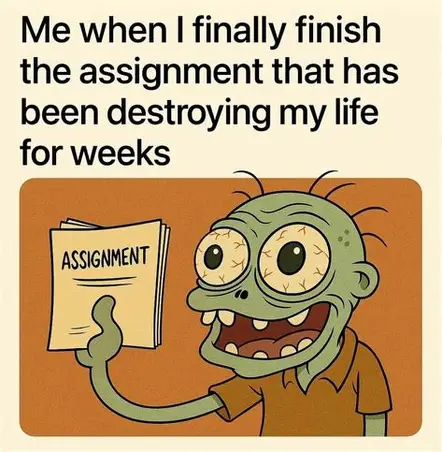